# Analysis and Visualisations

This notebook analyses how weather severity affects Yellow Taxi drivers' earnings potential across NYC zones, different precipitation types and temporal conditions.

In [1]:
# Importing the libraries required throughout the notebook
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Creating the directory to store output figures
outputs_dir = Path("../outputs")
outputs_dir.mkdir(parents=True, exist_ok=True)

# Initialising the Spark session for the analysis
spark = (
    SparkSession.builder
    .appName("MAST30034_Project1_analysis")
    .config("spark.driver.memory", "1500m")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

# Loading the aggregated training and test datasets
train_agg = spark.read.parquet("../data/processed/train_agg.parquet")
test_agg = spark.read.parquet("../data/processed/test_agg.parquet")

# Combining the training and test sets to analyse the full dataset
analysis_agg = train_agg.unionByName(test_agg)

print(f"train_agg: {train_agg.count():,} rows")
print(f"test_agg:  {test_agg.count():,} rows")
print(f"analysis_agg (combined): {analysis_agg.count():,} rows, {len(analysis_agg.columns)} columns")

analysis_agg.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/31 18:23:29 WARN Utils: Your hostname, MAHIKA-F8R8E40, resolves to a loopback address: 127.0.1.1; using 192.168.21.80 instead (on interface eth0)
26/08/31 18:23:29 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/31 18:23:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/08/31 18:23:34 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


train_agg: 32,983 rows
test_agg:  16,320 rows
analysis_agg (combined): 49,303 rows, 11 columns
root
 |-- PULocationID: integer (nullable = true)
 |-- severity_cat: string (nullable = true)
 |-- week_day: integer (nullable = true)
 |-- precip_type: string (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- total_fare: double (nullable = true)
 |-- total_duration_min: double (nullable = true)
 |-- trip_count: long (nullable = true)
 |-- avg_severity_score: double (nullable = true)
 |-- earnings_potential: double (nullable = true)
 |-- adj_earnings_potential: double (nullable = true)



In [2]:
# Setting thresholds for the trip count and duration adjustments
trips_thresh = 30       
duration_thresh = 60 

severity_order = ["normal", "mild", "moderate", "high"]

# Calculating total fare and trip duration across all groups
overall_totals = analysis_agg.select(
    F.sum("total_fare").alias("total_fare"),
    F.sum("total_duration_min").alias("total_duration_min")
).collect()[0]

# Calculating the overall earnings per active hour
overall_earnings = (
    overall_totals["total_fare"] /
    (overall_totals["total_duration_min"] / 60)
)

print(f"Global earnings baseline: ${overall_earnings:.2f}/hour")

def add_adjustment(df):

    """
    Calculates earnings_potential for the current aggregated
    groups and shrinks these estimates towards the overall dataset earnings
    baseline based on the number of trips and total trip duration in each group.

    Parameters:
    df: Current aggregated PySpark DataFrame

    Returns:
    PySpark DataFrame with the adj_earnings_potential feature added

    """

    return (
        df
        # Calculating raw earnings potential per active hour
        .withColumn("earnings_potential", F.col("total_fare") / (F.col("total_duration_min") / 60))

        # Calculating the weight based on the number of trips in each group
        .withColumn("trip_reliability", 
                    F.col("trip_count") / 
                    (F.col("trip_count") + F.lit(trips_thresh))
                    )

        # Calculating the weight based on total trip duration in each group
        .withColumn("duration_reliability", 
                    F.col("total_duration_min") /
                    (F.col("total_duration_min") + F.lit(duration_thresh))
                    )

        # Combining the trip count and duration weights
        .withColumn("reliability_weight", 
                    (F.col("trip_reliability") + F.col("duration_reliability")) 
                    / F.lit(2)
                    )

        # Shrinking group earnings potential towards the overall dataset baseline
        # Reference: Damien, "Shrinkage and Empirical Bayes to Improve Inference"
        .withColumn(
            "adj_earnings_potential",
            F.col("reliability_weight") * F.col("earnings_potential")
            + (
                (F.lit(1) - F.col("reliability_weight"))
                * F.lit(overall_earnings)
            )
        )
    )

Global earnings baseline: $68.20/hour


## 1. Overall Earnings Potential Across NYC Zones

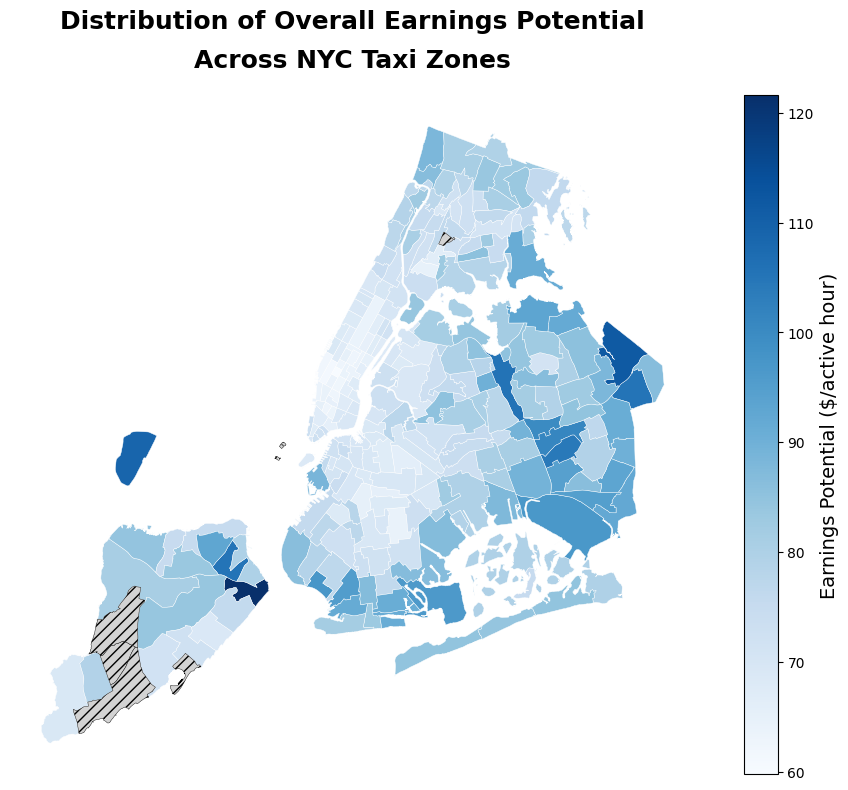

In [3]:
# Loading the NYC taxi zone boundaries
zones = gpd.read_file("../data/raw/taxi_zones/taxi_zones.shp")
zones["LocationID"] = zones["LocationID"].astype(int)

# Calculating the overall earnings potential for each pickup zone
zone_overall = (
    analysis_agg
    .groupBy("PULocationID")
    .agg(
        F.sum("total_fare").alias("total_fare"),
        F.sum("total_duration_min").alias("total_duration_min"),
        F.sum("trip_count").alias("trip_count"),
    )
    .transform(add_adjustment)
)

# Calculating high severity earnings potential for each pickup zone
zone_high_sev = (
    analysis_agg
    .filter(F.col("severity_cat") == "high")
    .groupBy("PULocationID")
    .agg(
        F.sum("total_fare").alias("total_fare"),
        F.sum("total_duration_min").alias("total_duration_min"),
        F.sum("trip_count").alias("trip_count"),
    )
    .transform(add_adjustment)
)

# Joining overall and high severity earnings potential by pickup zone
zone_change = (
    zone_overall.select("PULocationID", F.col("adj_earnings_potential").alias("overall_earnings"))
    .join(
        zone_high_sev.select("PULocationID", F.col("adj_earnings_potential").alias("high_earnings")),
        on="PULocationID", how="left"
    )
    # Calculating the change in earnings potential from overall to high severity
    .withColumn("earnings_change", F.col("high_earnings") - F.col("overall_earnings"))
)

# Converting the zone-level results to Pandas
zone_change_pd = zone_change.toPandas()
zone_change_pd["PULocationID"] = zone_change_pd["PULocationID"].astype(int)

# Converting the zone-level results to Pandas for mapping
zone_overall_pd = zone_overall.select(
    "PULocationID", F.col("adj_earnings_potential").alias("overall_earnings")
).toPandas()
zone_overall_pd["PULocationID"] = zone_overall_pd["PULocationID"].astype(int)

# Joining overall earnings potential results with the taxi zone boundaries
zone_overall_map = zones.merge(
    zone_overall_pd, left_on="LocationID", right_on="PULocationID", how="left")

# Plotting the overall distribution of adjusted earnings potential across NYC taxi zones
fig, ax = plt.subplots(figsize=(10, 8))

zone_overall_map.plot(
    column="overall_earnings", ax=ax, legend=True, 
    legend_kwds={'label': 'Earnings Potential ($/active hour)'},
    edgecolor="white", linewidth=0.3, cmap="Blues",
    # Zones without trip records have no adjusted earnings potential estimate 
    missing_kwds={"color": "lightgrey", "edgecolor": "black", "hatch": "///", "label": "No data"}
)  

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("Earnings Potential ($/active hour)", fontsize=14)
ax.set_title(
    "Distribution of Overall Earnings Potential\nAcross NYC Taxi Zones",
    fontsize=18, fontweight='bold', pad=20, linespacing=1.8
)
ax.axis("off") 
plt.tight_layout()
plt.savefig(outputs_dir / "overall_earnings_distribution_map.png", dpi=150, bbox_inches="tight")
plt.show()

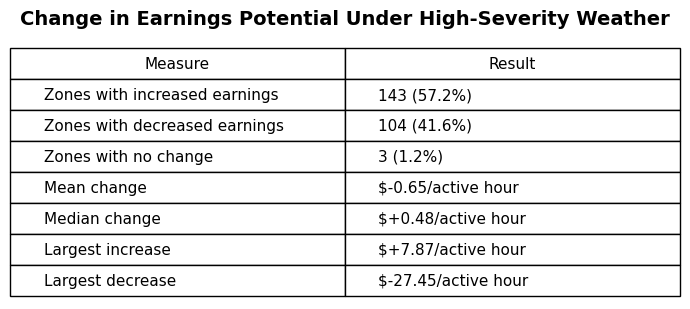

                               Zone       Borough  earnings_change
            Arrochar/Fort Wadsworth Staten Island       -27.446838
                Grymes Hill/Clifton Staten Island       -18.026886
                    Mariners Harbor Staten Island       -16.140198
                     Newark Airport           EWR       -14.083397
            Allerton/Pelham Gardens         Bronx        -9.854598
                            Bayside        Queens        -9.129221
            Bay Terrace/Fort Totten        Queens        -8.997677
                       Howard Beach        Queens        -8.453735
                         Douglaston        Queens        -8.398305
Riverdale/North Riverdale/Fieldston         Bronx        -7.540290


In [4]:
# Identifying zones with available earnings change data
change_data = zone_change_pd[zone_change_pd["earnings_change"].notna()].copy()
n_zones_with_data = len(change_data)

# Counting zones with increased or decreased earnings potential
n_increased = (change_data["earnings_change"] > 0).sum()
n_decreased = (change_data["earnings_change"] < 0).sum()
n_unchanged = (change_data["earnings_change"] == 0).sum()

percentage_increased = (n_increased / n_zones_with_data * 100)
percentage_decreased = (n_decreased / n_zones_with_data * 100)
percentage_unchanged = (n_unchanged / n_zones_with_data * 100)

# Building a summary table of the earnings change results
summary_table = pd.DataFrame({
    "Measure": [
        "Zones with increased earnings",
        "Zones with decreased earnings",
        "Zones with no change",
        "Mean change",
        "Median change",
        "Largest increase",
        "Largest decrease",
    ],
    "Result": [
        f"{n_increased} ({percentage_increased:.1f}%)",
        f"{n_decreased} ({percentage_decreased:.1f}%)",
        f"{n_unchanged} ({percentage_unchanged:.1f}%)",
        f"${change_data['earnings_change'].mean():+.2f}/active hour",
        f"${change_data['earnings_change'].median():+.2f}/active hour",
        f"${change_data['earnings_change'].max():+.2f}/active hour",
        f"${change_data['earnings_change'].min():+.2f}/active hour",
    ]
})

# Plotting the earnings change summary as a table
fig, ax = plt.subplots(figsize=(7, 3.2))

ax.axis("off")

change_table_plot = ax.table(
    cellText=summary_table.values,
    colLabels=["Measure", "Result"],
    cellLoc="left",
    loc="center"
)

change_table_plot.auto_set_font_size(False)
change_table_plot.set_fontsize(11)
change_table_plot.scale(1, 1.8)

plt.title("Change in Earnings Potential Under High-Severity Weather", 
          fontsize=14, pad=15, fontweight='bold', linespacing=1.8
        )

plt.tight_layout()
plt.savefig(outputs_dir / "earnings_change_summary_table.png", dpi=200, bbox_inches="tight")
plt.show()

zone_lookup = pd.read_csv("../data/raw/taxi_zone_lookup.csv")

# Adding zone names and boroughs to the decreasing zones
decreasing_zones = change_data[change_data["earnings_change"] < 0].merge(
    zone_lookup[["LocationID", "Zone", "Borough"]],
    left_on="PULocationID", right_on="LocationID", how="left"
)

# Identifying the top 10 zones with the largest decreases in earnings potential
worst_zones = decreasing_zones.nsmallest(10, "earnings_change")
print(worst_zones[["Zone", "Borough", "earnings_change"]].to_string(index=False))

## 2. Earnings Potential by Time of Day and Weather Severity

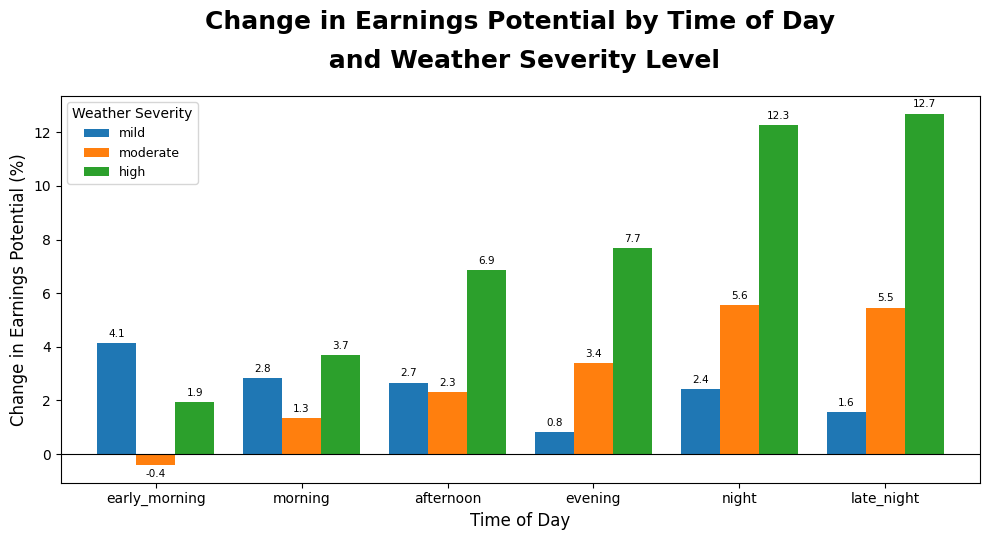

In [5]:
# Calculating earnings potential by time of day and weather severity
time_severity = (
    analysis_agg
    .groupBy("time_of_day", "severity_cat")
    .agg(
        F.sum("total_fare").alias("total_fare"),
        F.sum("total_duration_min").alias("total_duration_min"),
        F.sum("trip_count").alias("trip_count")
    )
    .transform(add_adjustment)
)

# Selecting variables required for the visualisation and converting to Pandas
time_severity = time_severity.select(
    "time_of_day",
    "severity_cat",
    "adj_earnings_potential"
).toPandas()

# Ordering time periods and weather severity categories
time_order = ["early_morning", "morning", "afternoon", "evening", "night", "late_night"]

time_severity["time_of_day"] = pd.Categorical(
    time_severity["time_of_day"],
    categories=time_order,
    ordered=True
)

time_severity["severity_cat"] = pd.Categorical(
    time_severity["severity_cat"],
    categories=severity_order,
    ordered=True
)

time_severity = time_severity.sort_values(["time_of_day", "severity_cat"])

# Restructuring the data for comparison 
time_comparison = time_severity.pivot(
    index="time_of_day",
    columns="severity_cat",
    values="adj_earnings_potential"
)

# Storing the normal-weather earnings as the reference
normal_reference = time_comparison["normal"].copy()

# Calculating percentage change from normal weather
for severity in severity_order:
    time_comparison[severity] = (
        (time_comparison[severity] - normal_reference)
        / normal_reference
    ) * 100

# Removing normal weather from the visualisation 
time_comparison = time_comparison.drop(columns="normal")


# Plotting percentage change in earnings potential by time of day
fig, ax = plt.subplots(figsize=(10, 5.5))

time_comparison.plot(kind="bar", ax=ax, width=0.8)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        fontsize=7.5,
        padding=3
    )

ax.axhline(0, color="black", linewidth=0.8)

ax.set_title("Change in Earnings Potential by Time of Day\n and Weather Severity Level", 
             fontsize=18, fontweight='bold', pad=20, linespacing=1.8)

ax.set_xlabel("Time of Day", fontsize=12)
ax.set_ylabel("Change in Earnings Potential (%)", fontsize=12)

ax.legend(title="Weather Severity", fontsize=9)

ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

plt.savefig(outputs_dir / "time_of_day_severity_change.png", dpi=150, bbox_inches="tight")

plt.show()

## 3. Earnings Potential by Precipitation Type

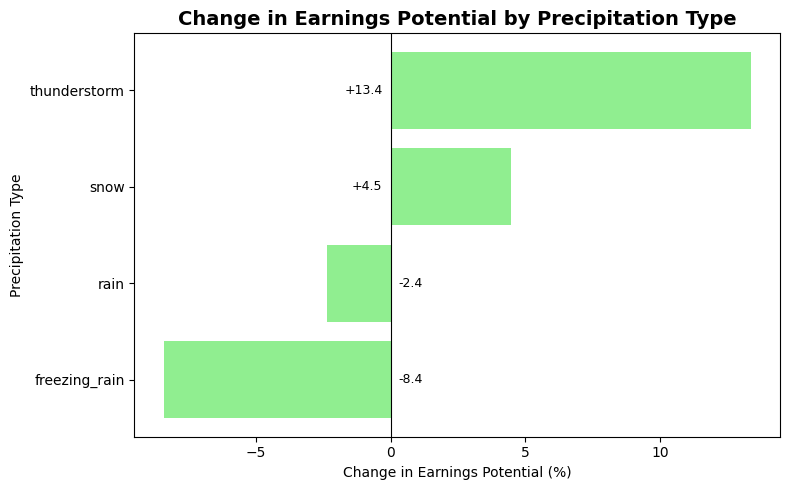

In [6]:
# Calculating earnings potential by precipitation type
earnings_by_precip_type = (
    analysis_agg
    .groupBy("precip_type")
    .agg(
        F.sum("total_fare").alias("total_fare"),
        F.sum("total_duration_min").alias("total_duration_min"),
        F.sum("trip_count").alias("trip_count")
    )
    .transform(add_adjustment)
)

# Selecting variables required for the visualisation and converting to Pandas
earnings_by_precip_type = earnings_by_precip_type.select(
    "precip_type",
    "trip_count",
    "adj_earnings_potential"
).toPandas()

# Getting earnings potential for no precipitation
no_precipitation_earnings = earnings_by_precip_type.loc[
    earnings_by_precip_type["precip_type"] == "no_prec",
    "adj_earnings_potential"
].values[0]

# Calculating percentage change in earnings potential from no precipitation
earnings_by_precip_type["change_from_noprecip"] = (
    (earnings_by_precip_type["adj_earnings_potential"] - no_precipitation_earnings) 
     / no_precipitation_earnings * 100)

# Removing no precipitation from the visualisation because it is the 0% reference
earnings_by_precip_type = earnings_by_precip_type[
    earnings_by_precip_type["precip_type"] != "no_prec"
]

# Ordering precipitation types by percentage change
earnings_by_precip_type = earnings_by_precip_type.sort_values(
    "change_from_noprecip", ascending=True
    )

# Plotting percentage change in earnings potential by precipitation type
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(earnings_by_precip_type["precip_type"], earnings_by_precip_type["change_from_noprecip"], color="lightgreen")

for bar, val in zip(bars, earnings_by_precip_type["change_from_noprecip"]):
    
    if val >= 0:
        label_x = -0.3
        ha = "right"
    else:
        label_x = 0.3
        ha = "left"

    ax.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.1f}",
        va="center",
        ha=ha,
        fontsize=9
    )

ax.axvline(0, color="black", linewidth=0.8)

ax.set_xlabel("Change in Earnings Potential (%)")

ax.set_ylabel("Precipitation Type")

ax.set_title("Change in Earnings Potential by Precipitation Type", fontsize=14, fontweight='bold')

plt.tight_layout()

plt.savefig(outputs_dir / "precip_type_earnings.png", dpi=150, bbox_inches="tight")

plt.show()